In [1]:
!pip install tensorflow librosa soundfile tqdm
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
DATASET_PATH = "/content/drive/MyDrive/ISBInternshipAIML/datasets"
import os
os.listdir(DATASET_PATH)


['Hip-Hop',
 'film',
 'Classical',
 'Pop',
 'metal',
 'Folk',
 'Devotional',
 'EDM',
 'Rock']

In [3]:
import librosa
import numpy as np
from tqdm import tqdm

def extract_features(file_path, sr=22050, duration=15, n_mfcc=20):
    y, sr = librosa.load(file_path, sr=sr, duration=duration)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    mfcc = np.mean(mfcc.T, axis=0)
    return mfcc


In [5]:
features = []
for genre in os.listdir(DATASET_PATH):
    genre_path = os.path.join(DATASET_PATH, genre)
    for file in tqdm(os.listdir(genre_path)):
        if file.endswith(".mp3"):
            path = os.path.join(genre_path, file)
            try:
                feat = extract_features(path)
                features.append(feat)
            except Exception as e:
                print(f"Error with {path}: {e}")


100%|██████████| 2/2 [00:00<00:00, 18315.74it/s]


In [6]:
X = np.array(features)
print("Feature shape:", X.shape)

Feature shape: (533, 20)


In [7]:
import tensorflow as tf

input_dim = X.shape[1]
encoding_dim = 10  # compression level

W1 = tf.Variable(tf.random.normal([input_dim, encoding_dim], stddev=0.1))
b1 = tf.Variable(tf.zeros([encoding_dim]))
W2 = tf.Variable(tf.random.normal([encoding_dim, input_dim], stddev=0.1))
b2 = tf.Variable(tf.zeros([input_dim]))

optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)

def forward(x):
    encoded = tf.nn.tanh(tf.matmul(x, W1) + b1)
    decoded = tf.nn.tanh(tf.matmul(encoded, W2) + b2)
    return encoded, decoded

def compute_loss(x, reconstructed):
    return tf.reduce_mean(tf.square(x - reconstructed))


In [8]:
X_tf = tf.constant(X, dtype=tf.float32)

for epoch in range(100):
    with tf.GradientTape() as tape:
        _, reconstructed = forward(X_tf)
        loss = compute_loss(X_tf, reconstructed)
    grads = tape.gradient(loss, [W1, b1, W2, b2])
    optimizer.apply_gradients(zip(grads, [W1, b1, W2, b2]))

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1} | Loss: {loss.numpy():.4f}")


Epoch 10 | Loss: 3028.8594
Epoch 20 | Loss: 3020.6274
Epoch 30 | Loss: 3018.5981
Epoch 40 | Loss: 3017.8499
Epoch 50 | Loss: 3017.2852
Epoch 60 | Loss: 3016.8557
Epoch 70 | Loss: 3016.4822
Epoch 80 | Loss: 3016.2346
Epoch 90 | Loss: 3016.0413
Epoch 100 | Loss: 3015.9031


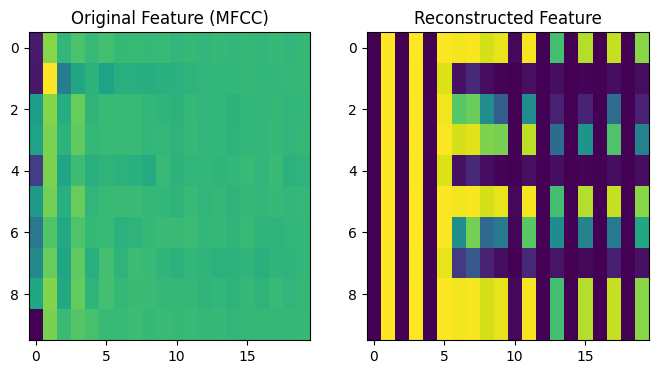

In [9]:
encoded, reconstructed = forward(X_tf)
encoded_np = encoded.numpy()
reconstructed_np = reconstructed.numpy()

import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.title("Original Feature (MFCC)")
plt.imshow(X[:10], aspect='auto')
plt.subplot(1,2,2)
plt.title("Reconstructed Feature")
plt.imshow(reconstructed_np[:10], aspect='auto')
plt.show()


In [10]:
np.savez("simple_autoencoder_weights.npz",
         W1=W1.numpy(), b1=b1.numpy(),
         W2=W2.numpy(), b2=b2.numpy())
